# D. PRAKTIKUM

## Identitas
- Nama: Radit Firansah
- NIM: 244107020196

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage.io
from skimage import io

In [3]:
img = cv2.imread('img/WhatsApp Image 2026-09-07 at 20.39.03.jpeg')

Resolusi gambar:  1600  x  1026


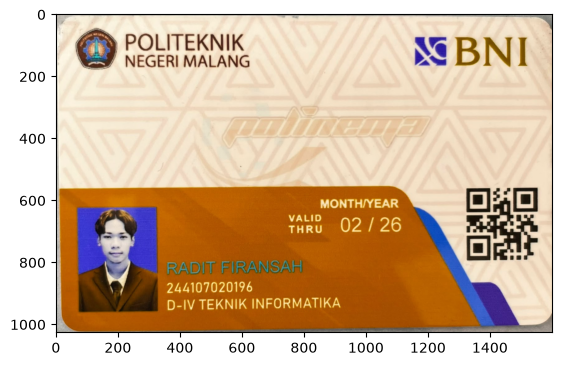

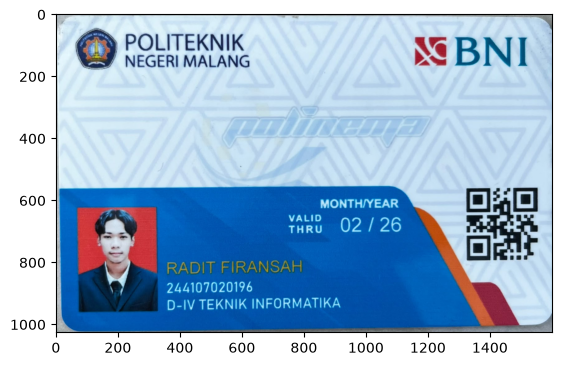

In [4]:
print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])
plt.imshow(img)
plt.show()

img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img2)
plt.show()

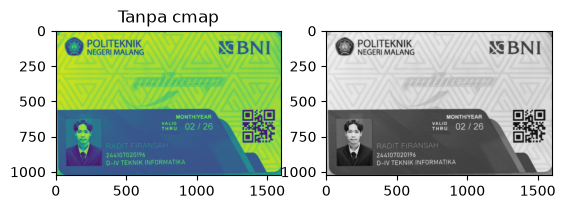

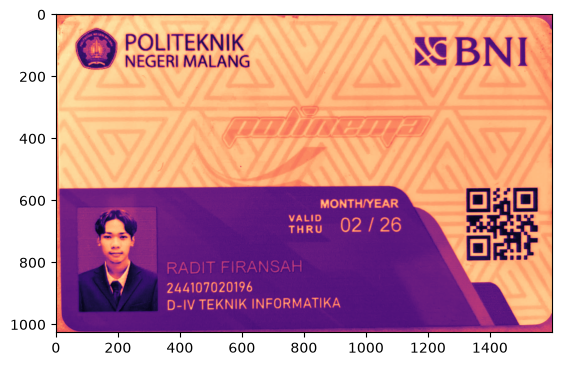

In [5]:
img_gray = cv2.imread('img/WhatsApp Image 2026-09-07 at 20.39.03.jpeg', cv2.IMREAD_GRAYSCALE)

plt.subplot(1, 2, 1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.show()

plt.imshow(img_gray, cmap='magma')
plt.show()

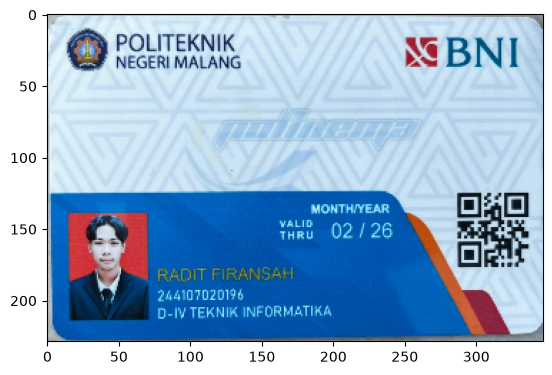

In [6]:
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_output = cv2.resize(imgRGB, (347, 229))
plt.imshow(img_output)
plt.show()

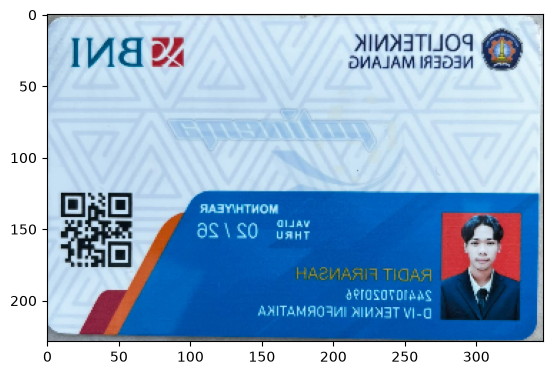

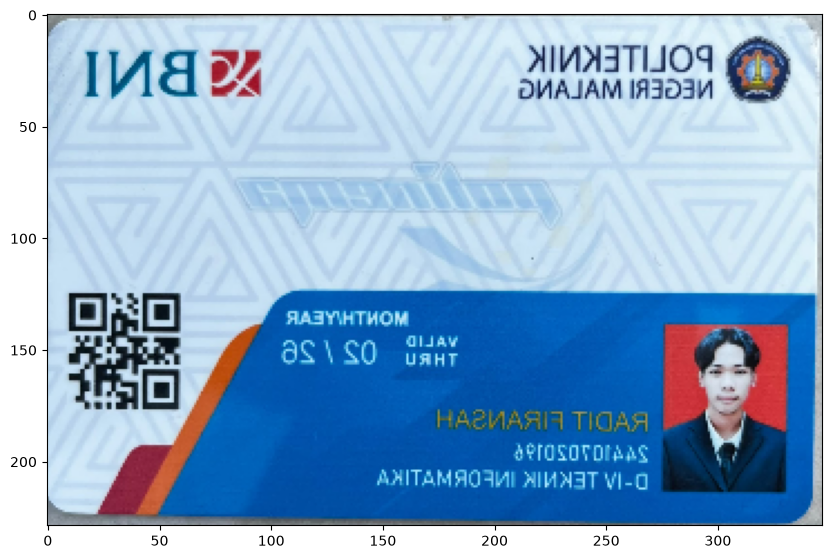

In [7]:
imgFlip = cv2.flip(img_output, 1)
plt.imshow(imgFlip)
plt.show()

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1)
ax.imshow(imgFlip)
plt.show()

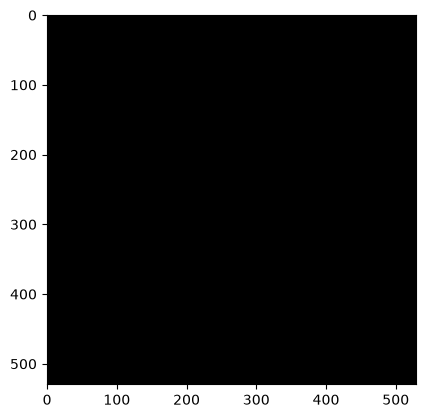

In [8]:
black_img = np.zeros(shape=(530, 530, 3), dtype=np.int16)
plt.imshow(black_img)

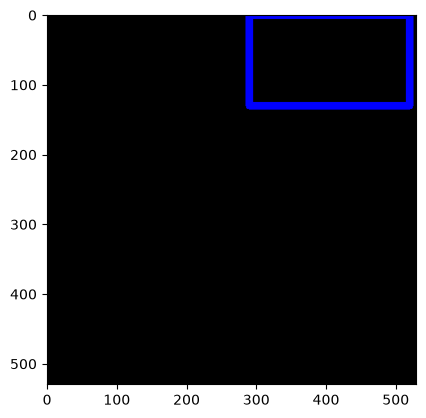

In [9]:
cv2.rectangle(black_img, pt1=(290, 0), pt2=(520, 130), color=(0, 0, 255), thickness=10)
plt.imshow(black_img)

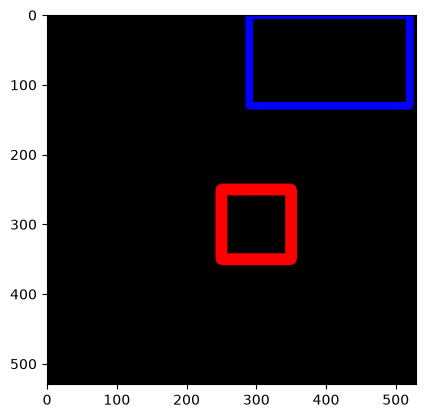

In [10]:
cv2.rectangle(black_img, pt1=(250, 250), pt2=(350, 350), color=(255, 0, 0), thickness=15)
plt.imshow(black_img)

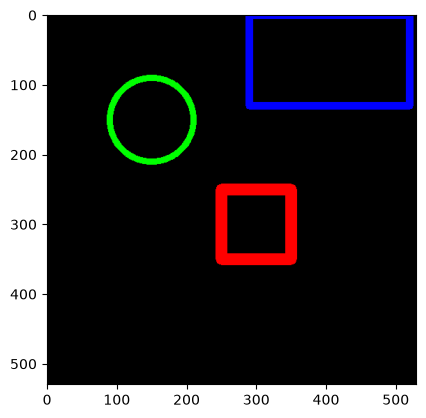

In [11]:
cv2.circle(black_img, center=(150, 150), radius=60, color=(0, 255, 0), thickness=8)
plt.imshow(black_img)

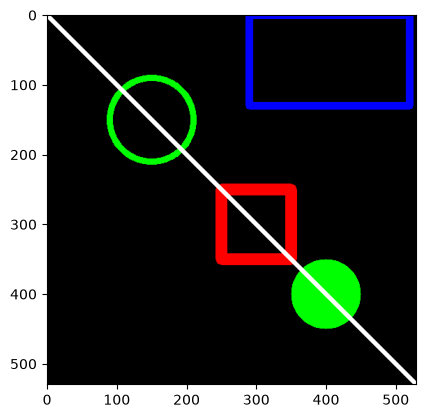

In [12]:
cv2.circle(black_img, center=(400, 400), radius=50, color=(0, 255, 0), thickness=-1)
cv2.line(black_img, pt1=(0, 0), pt2=(530, 530), color=(255, 255, 255), thickness=5)
plt.imshow(black_img)

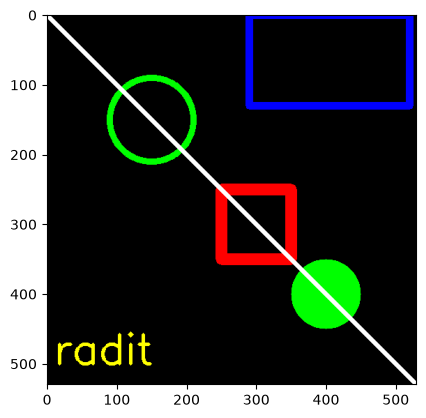

In [13]:
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(black_img, text='radit', org=(10, 500), fontFace=font, fontScale=2, color=(255, 255, 0), thickness=3, lineType=cv2.LINE_AA)

plt.imshow(black_img)
plt.show()

In [14]:
vertices = np.array([[150,350],[250,250],[450,350],[250,450]],dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [15]:
pts = vertices.reshape((-1,1,2)) 
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

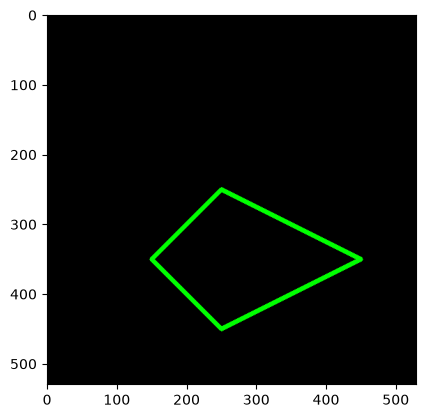

In [16]:
black_img2 = np.zeros(shape=(530, 530, 3), dtype=np.int32)
cv2.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)

# PERTANYAAN PRAKTIKUM

### Pertanyaan 1
Tampilkan satu citra bebas menggunakan `cv2_imshow()` / `cv2.imshow()` dan `plt.imshow()` tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.


qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/radit/.conda/envs/vision/lib/python3.12/site-packages/cv2/qt/plugins"


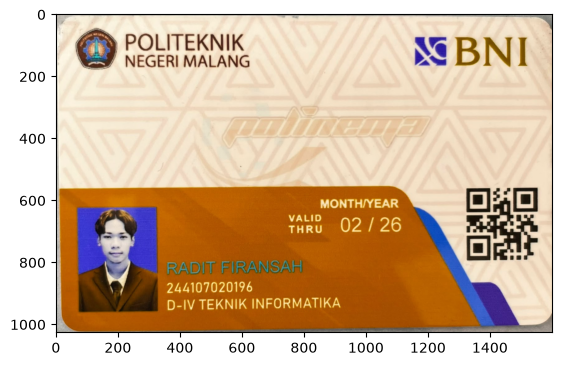

Pixel OpenCV     : [111 115 144]
Pixel Matplotlib : [111 115 144]


In [17]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("img/WhatsApp Image 2026-09-07 at 20.39.03.jpeg")

cv2.imshow("OpenCV", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

plt.imshow(img)
plt.show()

print("Pixel OpenCV     :", img[100, 100])
print("Pixel Matplotlib :", img[100, 100])

**Jawaban:**
Hasilnya berbeda karena `cv2.imread()` membaca citra dalam urutan kanal **BGR** (Blue, Green, Red), sedangkan `plt.imshow()` pada Matplotlib mengasumsikan input citra dalam urutan **RGB** (Red, Green, Blue). Pembacaan dengan `skimage.io.imread()` membaca citra secara langsung dalam format **RGB**.

cara display image menggunakan `cv2.imread()` dan juga `plt.imshow(img)` berbeda jika cv2 membuka display baru bukan display di file ipynb nya.

### Pertanyaan 2
Buat kanvas hitam berukuran sama dengan tipe data `int16` dan `int32`. Bandingkan `dtype`, `min()`, `max()`, dan `nbytes` keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.


In [18]:
import numpy as np
import cv2

img16 = np.zeros((500, 500, 3), dtype=np.int16)
img32 = np.zeros((500, 500, 3), dtype=np.int32)

cv2.imshow("int16", img16.astype(np.uint8))
cv2.imshow("int32", img32.astype(np.uint8))

print("int16")
print("dtype :", img16.dtype)
print("min   :", img16.min())
print("max   :", img16.max())
print("nbytes:", img16.nbytes)

print("\nint32")
print("dtype :", img32.dtype)
print("min   :", img32.min())
print("max   :", img32.max())
print("nbytes:", img32.nbytes)

cv2.waitKey(0)
cv2.destroyAllWindows()

int16
dtype : int16
min   : 0
max   : 0
nbytes: 1500000

int32
dtype : int32
min   : 0
max   : 0
nbytes: 3000000


**Jawaban:**
Tampilannya **sama** (sama-sama hitam polos karena seluruh piksel bernilai 0). Namun, ukuran memorinya (`nbytes`) **berbeda**. Tipe data `int16` menggunakan 2 byte (16 bit) per elemen/nilai, sedangkan `int32` menggunakan 4 byte (32 bit) per elemen. Oleh karena itu, kanvas dengan `int32` membutuhkan alokasi memori tepat 2 kali lebih besar daripada kanvas `int16`.

### Pertanyaan 3
Apa kegunaan baris `from google.colab.patches import cv2_imshow`, dan mengapa `cv2.imshow()` bawaan OpenCV tidak dapat dipakai di Google Colab?

**Jawaban:**
Fungsi `cv2.imshow()` bawaan OpenCV membutuhkan jendela GUI. Di lingkungan cloud/notebook seperti Google Colab (atau server Jupyter headless), tidak ada layar GUI desktop interaktif sehingga pemanggilan `cv2.imshow()` akan menimbulkan error (*crash*). Baris `from google.colab.patches import cv2_imshow` mengimpor fungsi tambalan (*patch*) yang mengubah array citra OpenCV menjadi gambar PNG/JPEG inline untuk ditampilkan langsung di sel notebook.

pada praktikum ini saya tidak menggunakan Colab karena lebih nyaman di environtment local.


### Pertanyaan 4
Citra yang dibaca dengan `skimage.io.imread()` ditampilkan berdampingan dengan hasil `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` atas citra yang sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan visual saja.

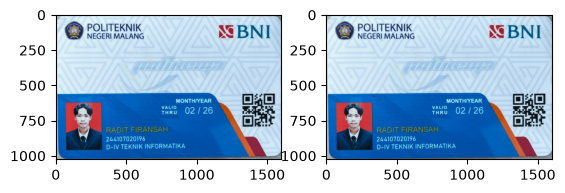

Pixel skimage : [144 115 111]
Pixel cv2 RGB : [144 115 111]


In [19]:
img_skimage = io.imread("img/WhatsApp Image 2026-09-07 at 20.39.03.jpeg")
img_cv2 = cv2.imread("img/WhatsApp Image 2026-09-07 at 20.39.03.jpeg")

img_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

plt.subplot(1, 2, 1)
plt.imshow(img_skimage)

plt.subplot(1, 2, 2)
plt.imshow(img_rgb)

plt.show()

print("Pixel skimage :", img_skimage[100, 100])
print("Pixel cv2 RGB :", img_rgb[100, 100])

**Jawaban:**
**Kedua-duanya menampilkan warna sebenarnya**. `skimage.io.imread()` membaca citra secara asli dalam urutan RGB `[R, G, B]`. Sedangkan `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` mengonversi citra BGR hasil OpenCV `[B, G, R]` menjadi urutan RGB `[R, G, B]`. Tidak ada yang kanalnya tertukar di antara kedua hasil tersebut karena keduanya sudah berada pada ruang warna RGB.

### Pertanyaan 5
Setelah citra ditampilkan dengan `figsize` yang jauh lebih besar, apakah nilai `img.shape` ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra dan mengubah ukuran tampilan.

Shape awal: (1026, 1600, 3)


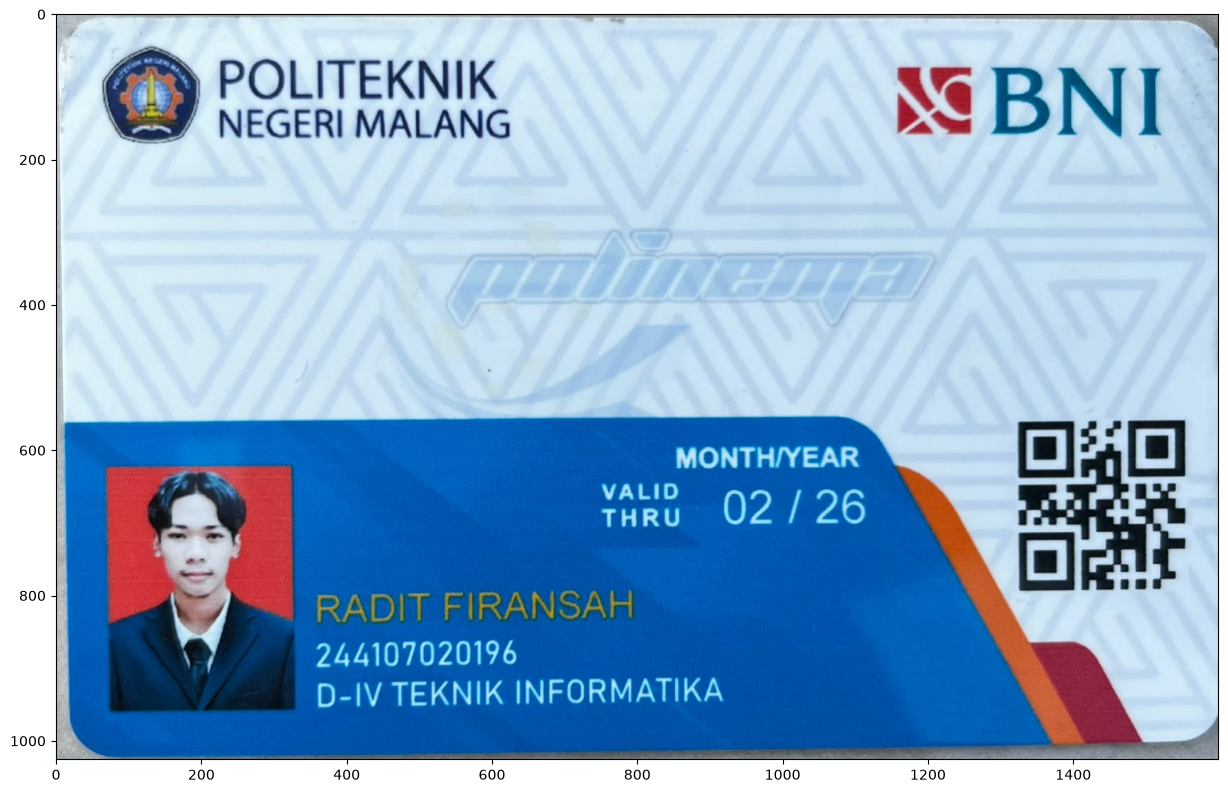

Shape citra setelah cv2.resize    : (200, 200, 3)


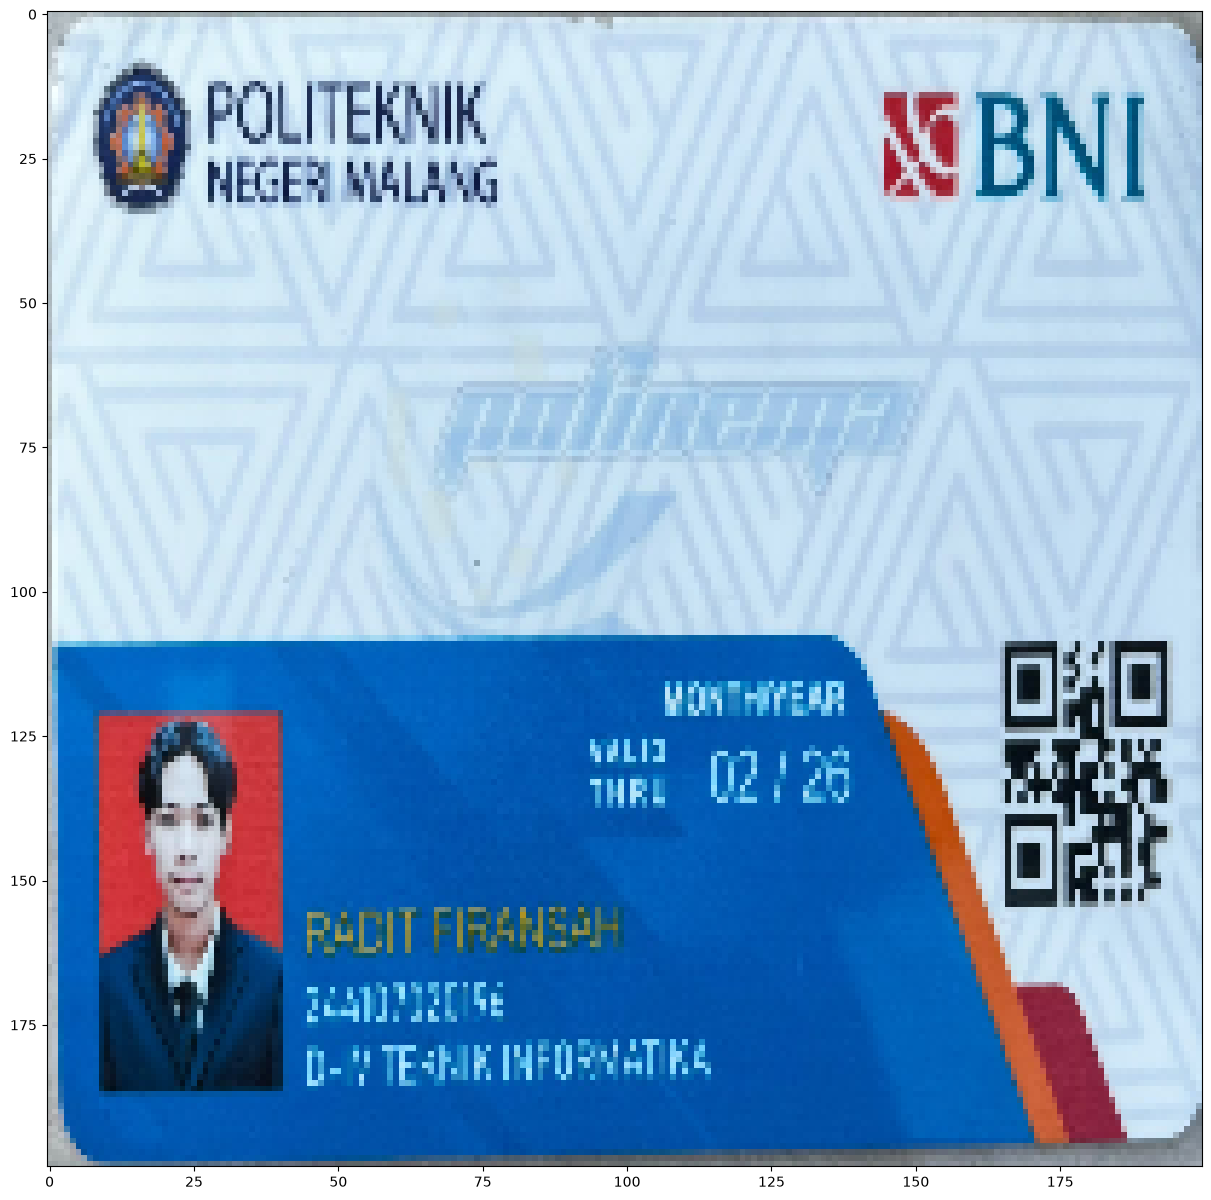

In [20]:
# Pembuktian Pertanyaan 5
img_test = cv2.cvtColor(cv2.imread('img/WhatsApp Image 2026-09-07 at 20.39.03.jpeg'), cv2.COLOR_BGR2RGB)

print("Shape awal:", img_test.shape)

plt.figure(figsize=(15, 15))
plt.imshow(img_test)
plt.show()

img_resized_test = cv2.resize(img_test, (200, 200))
print("Shape citra setelah cv2.resize    :", img_resized_test.shape)
plt.figure(figsize=(15, 15))
plt.imshow(img_resized_test)
plt.show()

**Jawaban:**
Nilai `img.shape` **tidak ikut berubah**.
- **Mengubah ukuran tampilan (`figsize`)**: Hanya mengatur ukuran kanvas plot Matplotlib dalam inci ketika ditampilkan di layar, tanpa memodifikasi array piksel data citra.
- **Mengubah ukuran citra (`cv2.resize()`)**: Benar-benar mengubah dimensi matriks array piksel (jumlah baris dan kolom data citra) melalui proses interpolasi.


# TUGAS PRAKTIKUM - Penerapan

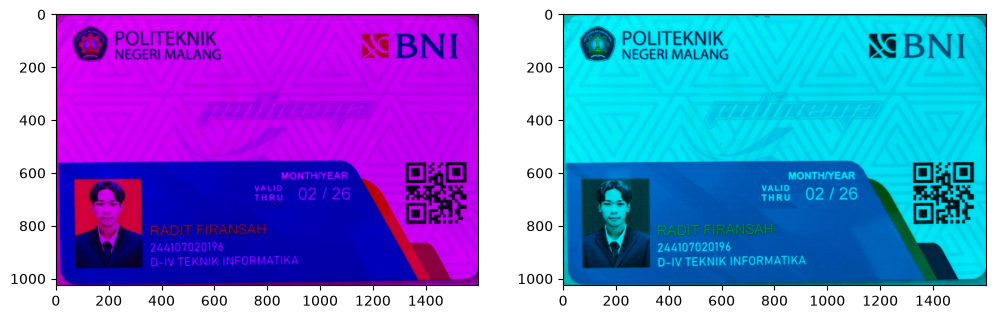

In [21]:
img_src = cv2.cvtColor(cv2.imread('img/WhatsApp Image 2026-09-07 at 20.39.03.jpeg'), cv2.COLOR_BGR2RGB)

img_rb = img_src.copy()
img_rb[:, :, 1] = 0 

img_gb = img_src.copy()
img_gb[:, :, 0] = 0  

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_rb)
axes[1].imshow(img_gb)

plt.show()

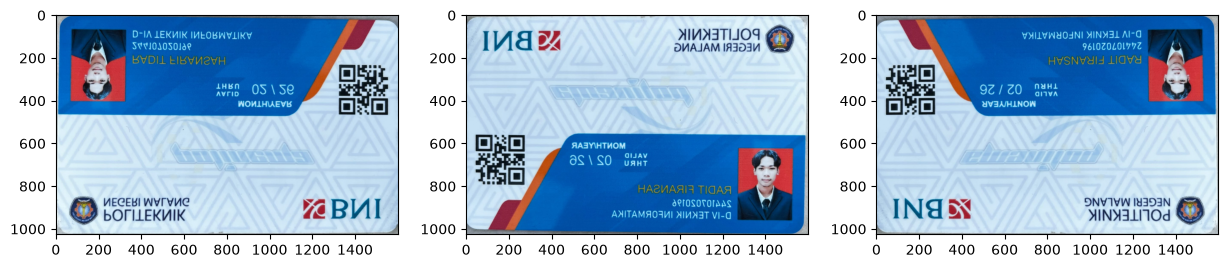

In [22]:
flip_vert = cv2.flip(img_src, 0)
flip_horiz = cv2.flip(img_src, 1)
flip_both = cv2.flip(img_src, -1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(flip_vert)
axes[1].imshow(flip_horiz)
axes[2].imshow(flip_both)
plt.show()

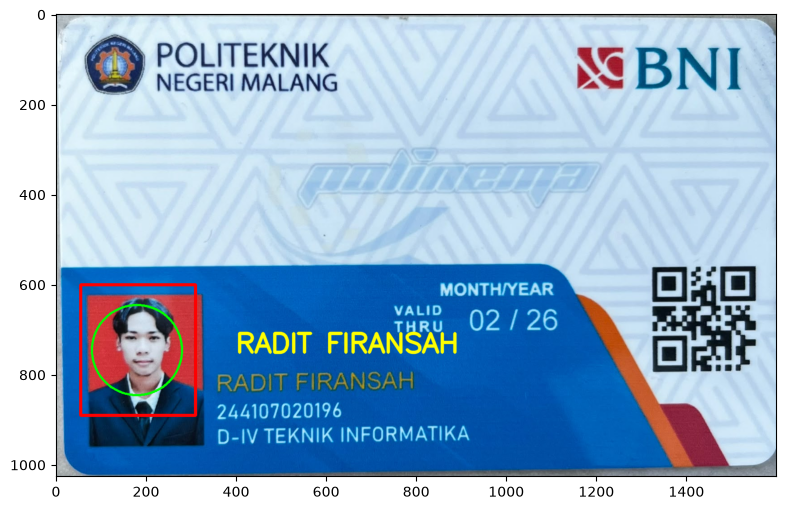

In [23]:
img_draw = img_src.copy()
cv2.rectangle(img_draw, pt1=(55, 600), pt2=(310, 890), color=(255, 0, 0), thickness=5)

cv2.circle(img_draw, center=(180, 745), radius=100, color=(0, 255, 0), thickness=4)

font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(img_draw, text='RADIT FIRANSAH', org=(400, 750), fontFace=font, fontScale=2.0, color=(255, 255, 0), thickness=5, lineType=cv2.LINE_AA)

plt.figure(figsize=(10, 6))
plt.imshow(img_draw)
plt.show()

### TUGAS PRAKTIKUM - Analisa
1. Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab
menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen
piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah
mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?
Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan
kesimpulan Anda.

**Pertanyaan**
Menghitung nilai rata-rata intensitas piksel.

In [24]:
img = cv2.imread("img/WhatsApp Image 2026-09-07 at 20.39.03.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print("Rata-rata intensitas:", gray.mean())

Rata-rata intensitas: 157.77134624756334


# TUGAS PRAKTIKUM - Aplikasi

**Studi Kasus 1:** Panitia sebuah kegiatan perlu membubuhkan label identitas pada
ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel,
sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada
semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua
citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga
proporsinya tetap sama. Silakan melakukan akuisisi data sendiri, setiap anak
harus menggunakan image yang berbeda-beda

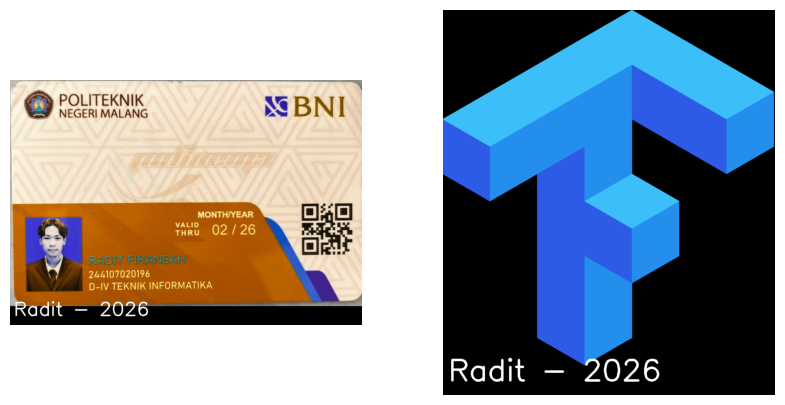

In [27]:
img1 = cv2.imread("img/WhatsApp Image 2026-09-07 at 20.39.03.jpeg")
img2= cv2.imread("img/22024tf.png")

def tambah_label(img):
    h, w = img.shape[:2]

    bar = h // 12
    canvas = np.zeros((h + bar, w, 3), dtype=np.uint8)
    canvas[0:h, :] = img

    cv2.putText(
        canvas,
        "Radit - 2026",
        (bar // 5, h + bar // 2),
        cv2.FONT_HERSHEY_SIMPLEX,
        bar / 30,
        (255, 255, 255),
        bar // 15
    )

    return canvas

# Tambahkan label ke kedua gambar
hasil1 = tambah_label(img1)
hasil2 = tambah_label(img2)

# Tampilkan 2 gambar
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(hasil1)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hasil2)
plt.axis("off")

plt.show()


**Studi Kasus 2:** Marketplace seperti Tokopedia dan Shopee menampilkan foto
produk dalam bingkai persegi 1:1. Foto penjual yang berukuran potrait atau
lanskap akan terpotong atau terlihat tidak proporsional bila diunggah begitu saja.
Bangun program yang mengubah foto berukuran apa pun menjadi thumbnail
persegi tanpa mengubah rasio aslinya, dengan sisa ruang diisi kanvas berwarna.
Dalam hal ini, rasio asli tetap terjaga, citra terpasang tepat di tengah kanvas,
tambahkan logo nama toko berukuran proporsional pada gambar.

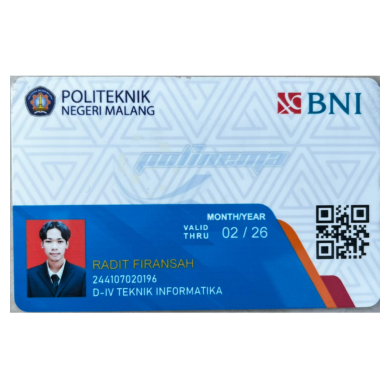

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("img/WhatsApp Image 2026-09-07 at 20.39.03.jpeg")
h, w = img.shape[:2]

if h > w:
    s = h
else:
    s = w

canvas = np.ones((s, s, 3), dtype=np.uint8) * 255

x = (s - w) // 2
y = (s - h) // 2

canvas[y:y+h, x:x+w] = img

plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()